In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

In [2]:
# # --- Load mapping files --- #
# def load_icd2ccsr(file="icdcode/icd2ccsr.txt"):
#     with open(file, "r") as f:
#         return dict(line.strip().split("\t") for line in f)

# def load_icd2ccs_and_ccsdesc(icd2ccs_file="icdcode/icd2ccs.txt", ccsdesc_file="icdcode/ccs2description.txt"):
#     with open(icd2ccs_file, "r") as f:
#         icd2ccs = dict(line.strip().split("\t") for line in f)
#     with open(ccsdesc_file, "r") as f:
#         ccs2desc = dict(line.strip().split("\t") for line in f)
#     return icd2ccs, ccs2desc

# icd2ccsr = load_icd2ccsr()
# icd2ccs, ccs2desc = load_icd2ccs_and_ccsdesc()

# # --- Load your actual dataset --- #
# df = pd.read_csv("Data/raw_data.csv")

# # --- Convert stringified ICD code lists into real Python lists --- #
# def parse_icd_column(text):
#     try:
#         return ast.literal_eval(text)
#     except:
#         return []

# df["icd_list"] = df["icd_code"].apply(parse_icd_column)

# # --- Flatten ICD codes --- #
# df["flat_icds"] = df["icd_list"].apply(
#     lambda lst: [str(code).strip() for code in lst if pd.notnull(code) and str(code).strip() != ""]
# )

# # --- Map to CCSR categories --- #
# def map_to_ccsr(icds):
#     return [icd2ccsr.get(code, "Unknown") for code in icds]

# df["ccsr_codes"] = df["flat_icds"].apply(map_to_ccsr)

# # --- Map to CCS descriptions --- #
# def map_to_ccs_desc(icds):
#     return [ccs2desc.get(icd2ccs.get(code, ""), "Unknown") for code in icds]

# df["ccs_desc"] = df["flat_icds"].apply(map_to_ccs_desc)

# # --- Flatten all mapped CCSR categories --- #
# all_ccsr_codes = [code for sublist in df["ccsr_codes"] for code in sublist if code != "Unknown"]
# ccsr_counts = pd.Series(Counter(all_ccsr_codes)).sort_values(ascending=False)

# # --- Plot top 20 CCSR categories --- #
# plt.figure(figsize=(12, 6))
# sns.barplot(x=ccsr_counts.head(20).index, y=ccsr_counts.head(20).values, palette="mako")
# plt.title("Distribution of Trials per CCSR Disease Category (from raw_data.csv)")
# plt.xlabel("CCSR Category")
# plt.ylabel("Number of Trials")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'Data/raw_data.csv'

C:\Users\Carol\AppData\Local\Temp\ipykernel_33536\2004930448.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ccsr_counts.head(20).index, y=ccsr_counts.head(20).values, palette="mako")


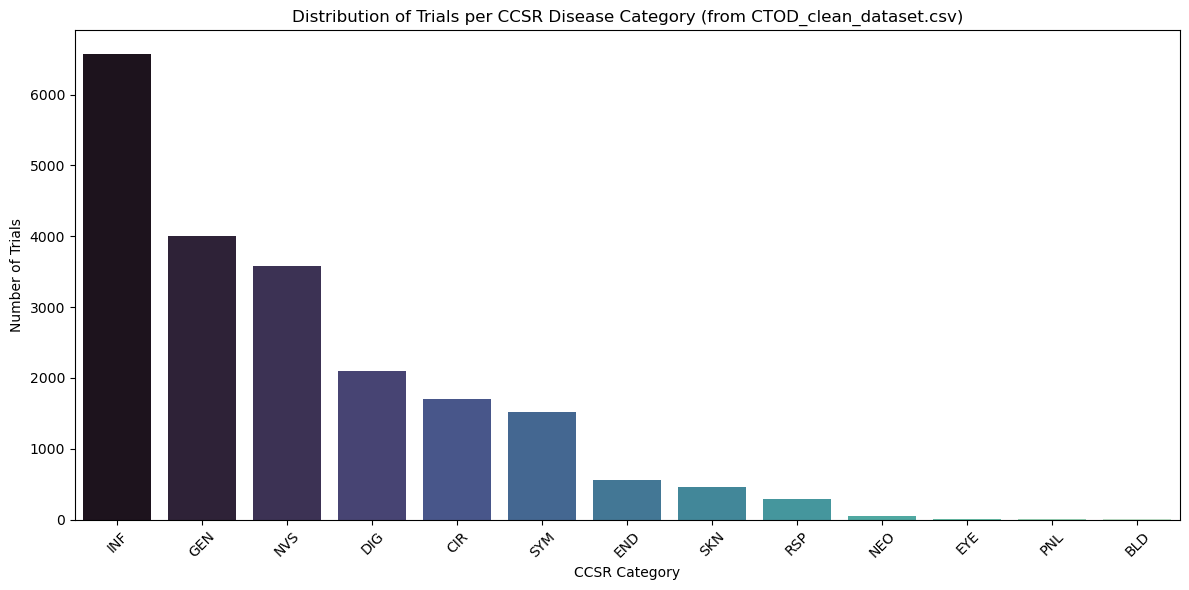

In [3]:
# --- Load mapping files --- #
def load_icd2ccsr(file="icdcode/icd2ccsr.txt"):
    with open(file, "r") as f:
        return dict(line.strip().split("\t") for line in f)

def load_icd2ccs_and_ccsdesc(icd2ccs_file="icdcode/icd2ccs.txt", ccsdesc_file="icdcode/ccs2description.txt"):
    with open(icd2ccs_file, "r") as f:
        icd2ccs = dict(line.strip().split("\t") for line in f)
    with open(ccsdesc_file, "r") as f:
        ccs2desc = dict(line.strip().split("\t") for line in f)
    return icd2ccs, ccs2desc

icd2ccsr = load_icd2ccsr()
icd2ccs, ccs2desc = load_icd2ccs_and_ccsdesc()

# --- Load your actual dataset --- #
df = pd.read_csv("CTOD_clean_dataset.csv")

# --- Convert stringified ICD code lists into real Python lists --- #
def parse_icd_column(text):
    try:
        return ast.literal_eval(text)
    except:
        return []

df["icd_list"] = df["icdcodes"].apply(parse_icd_column)

# --- Flatten ICD codes --- #
df["flat_icds"] = df["icd_list"].apply(
    lambda lst: [str(code).strip() for code in lst if pd.notnull(code) and str(code).strip() != ""]
)

# --- Map to CCSR categories --- #
def map_to_ccsr(icds):
    return [icd2ccsr.get(code, "Unknown") for code in icds]

df["ccsr_codes"] = df["flat_icds"].apply(map_to_ccsr)

# --- Map to CCS descriptions --- #
def map_to_ccs_desc(icds):
    return [ccs2desc.get(icd2ccs.get(code, ""), "Unknown") for code in icds]

df["ccs_desc"] = df["flat_icds"].apply(map_to_ccs_desc)

# --- Flatten all mapped CCSR categories --- #
all_ccsr_codes = [code for sublist in df["ccsr_codes"] for code in sublist if code != "Unknown"]
ccsr_counts = pd.Series(Counter(all_ccsr_codes)).sort_values(ascending=False)

# --- Plot top 20 CCSR categories --- #
plt.figure(figsize=(12, 6))
sns.barplot(x=ccsr_counts.head(20).index, y=ccsr_counts.head(20).values, palette="mako")
plt.title("Distribution of Trials per CCSR Disease Category (from CTOD_clean_dataset.csv)")
plt.xlabel("CCSR Category")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

def parse_icd_column(icd_text):
    try:
        return eval(icd_text) if isinstance(icd_text, str) else []
    except:
        return []

def extract_ccsr(df, icd2ccsr_dict, icd_column):
    df["icd_list"] = df[icd_column].apply(parse_icd_column)
    df["flat_icds"] = df["icd_list"].apply(
        lambda lst: [code.strip() for code in lst if isinstance(code, str) and code.strip() != ""]
    )
    df["CCSR"] = df["flat_icds"].apply(
        lambda codes: [icd2ccsr_dict.get(code, None) for code in codes]
    )
    df["CCSR"] = df["CCSR"].apply(lambda x: [i for i in x if i is not None])
    df["CCSR_MAIN"] = df["CCSR"].apply(lambda x: x[0] if len(x) > 0 else "UNKNOWN")
    return df

def stratified_sample(df, label_column, fraction, random_state=42):
    return df.groupby(label_column, group_keys=False).apply(
        lambda x: x.sample(frac=fraction, random_state=random_state)
    ).reset_index(drop=True)

def reduce_and_save(input_path, output_path, icd_column, icd2ccsr_dict, fraction=0.25):
    df = pd.read_csv(input_path)
    original_len = len(df)

    df = extract_ccsr(df, icd2ccsr_dict, icd_column)
    df_reduced = stratified_sample(df, "CCSR_MAIN", fraction=fraction)

    os.makedirs(output_path, exist_ok=True)
    out_file = os.path.join(output_path, os.path.basename(input_path))
    df_reduced.to_csv(out_file, index=False)

    print(f"{os.path.basename(input_path):25} {original_len:>8} → {len(df_reduced):>7}")
    return original_len, len(df_reduced)

# ------------------------------- #
#        Load ICD2CCSR            #
# ------------------------------- #
icd2ccsr_file = "icdcode/icd2ccsr.txt"
icd2ccsr = {}
with open(icd2ccsr_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            icd2ccsr[parts[0]] = parts[1]

# ------------------------------- #
#         Reduce CTOD             #
# ------------------------------- #
print("\nReducing CTOD dataset")
ctod_input_base = "data/labelling"
ctod_output_base = "data/labelling/labelling_reduced"
phases = ["I", "II", "III"]
ctod_summary = []

for phase in phases:
    for split in ["train", "valid"]:
        file = f"phase_{phase}_{split}.csv"
        input_path = os.path.join(ctod_input_base, file)
        if os.path.exists(input_path):
            original, reduced = reduce_and_save(
                input_path=input_path,
                output_path=ctod_output_base,
                icd_column="icdcodes",
                icd2ccsr_dict=icd2ccsr,
                fraction=0.25
            )
            ctod_summary.append((file, original, reduced))

# ------------------------------- #
#         Reduce HINT             #
# ------------------------------- #
"""
print("\nReducing HINT dataset")
hint_input_base = "data/clinical-trial-outcome-prediction/data"
hint_output_base = "data/clinical-trial-outcome-prediction/data_reduced"
phases = ["I", "II", "III"]
hint_summary = []

for phase in phases:
    for split in ["train", "valid", "test"]:  # You want valid included, so we keep all
        file = f"phase_{phase}_{split}.csv"
        input_path = os.path.join(hint_input_base, file)
        if os.path.exists(input_path):
            original, reduced = reduce_and_save(
                input_path=input_path,
                output_path=hint_output_base,
                icd_column="icd_code",
                icd2ccsr_dict=icd2ccsr,
                fraction=0.25
            )
            hint_summary.append((file, original, reduced))
"""
# ------------------------------- #
#         Summary Print           #
# ------------------------------- #

def print_summary(title, summary_list):
    print(f"\nSummary for {title}:")
    total_original = 0
    total_reduced = 0
    for name, orig, red in summary_list:
        print(f"{name:25} {orig:>8} → {red:>7}")
        total_original += orig
        total_reduced += red
    print(f"{'Total':25} {total_original:>8} → {total_reduced:>7}")

print_summary("CTOD", ctod_summary)
#print_summary("HINT", hint_summary)



Reducing CTOD dataset
phase_I_train.csv            16076 →    4016
phase_I_valid.csv             4019 →    1006
phase_II_train.csv           21568 →    5390
phase_II_valid.csv            5392 →    1348
phase_III_train.csv          14281 →    3572
phase_III_valid.csv           3571 →     893

Summary for CTOD:
phase_I_train.csv            16076 →    4016
phase_I_valid.csv             4019 →    1006
phase_II_train.csv           21568 →    5390
phase_II_valid.csv            5392 →    1348
phase_III_train.csv          14281 →    3572
phase_III_valid.csv           3571 →     893
Total                        64907 →   16225
